# INFO 264, Group Exam 2025
### Kandidate numbers: 0000, 0000, 0000, 0000
# Introduction
---
### <u>The Tasks</u>
<u>**Task 1:**</u>
* Create four machine learning models, one which have to be a neural network. The models will be used for labeling sentiment in a dataset containing hotel reviews.

<u>**Task 2:**</u>
* Create a convolutional nerual network, train it on the CIFAR-10 data set, specifically as a binary classifier on one of the categories in that data set.

# Task 1 Sentiment Analysis
---
### <u>The data</u>
The data has many columns containing data that is non-relevant for sentiment analysis. Columns with self-explainatory names, have no extra explanation.

#### <u>Non relevant data</u>
* `Hotel_Address` - String
* `Additional_Number_of_Scoring` - Unknown data value. Integer.
* `Review_Date` - String
* `Average_Score` - The hotels avarage score. Float
* `Hotel_Name` - String
* `Reviewer_Nationality` - String
* `Review_Total_Negative_Word_Counts` - Amount of words in a negative review. Integer
* `Total_Number_of_Reviews` - Amount of reviews for a given hotel. Integer
* `Review_Total_Positive_Word_Counts` - Amount of words in a positive review. Integer
* `Total_Number_of_Reviews_Reviewer_Has_Given` - Amount of reviews from user. Integer
* `Tags` - List of strings
* `Days_since_review` - String
* `lat` - Float
* `lng` - Float

It is important to note that this data is not relevant for our task, but could be useful for other sentiment tasks. If we were to expand our task, we could use some of the data to, for example, see if there's a relation between the sentiment and the reviewers nationality.

#### <u>Relevant data</u>
* `Negative_Review` - Review labeled as negative. String
* `Positive_Review` - Review labeled as positive. String
* `Reviewer_Score` - Score left by the reviewer. Float

Many reviews had both positive and negative labeled reviews, which has to be combined in order to analyse the sentiment left by the reviewer.
 

### <u>Preprocessing steps</u>
#### <u>Preprocessing setp 1. Data extraction</u>
`extract_relevant_csv_data()` extracts relevant data and returns a pandas dataframe. We clean this data thoroughly later.

In [1]:
import pandas as pd

def extract_relevant_csv_data(_file_path, _use_cols = ["Negative_Review", "Positive_Review", "Reviewer_Score"]):
    _dataset = pd.read_csv(_file_path, usecols = _use_cols)
    _new_dataset = []
    for i in _dataset.to_numpy():
        _new_dataset.append({"Reviewer_Score": i[2], "Positive_Review": i[0], "Negative_Review" : i[1]})
    return pd.DataFrame(_new_dataset)
data = extract_relevant_csv_data("./Hotel_Reviews.csv")
data # To display the data below

,Reviewer_Score,Positive_Review,Negative_Review
0,2.9,I am so angry that i made this post available...,Only the park outside of the hotel was beauti...
1,7.5,No Negative,No real complaints the hotel was great great ...
2,7.1,Rooms are nice but for elderly a bit difficul...,Location was good and staff were ok It is cut...
3,3.8,My room was dirty and I was afraid to walk ba...,Great location in nice surroundings the bar a...
4,6.7,You When I booked with your company on line y...,Amazing location and building Romantic setting
...,...,...,...
515733,7.0,no trolly or staff to help you take the lugga...,location
515734,5.8,The hotel looks like 3 but surely not 4,Breakfast was ok and we got earlier check in
515735,2.5,The ac was useless It was a hot week in vienn...,No Positive
515736,8.8,No Negative,The rooms are enormous and really comfortable...


#### <u>Preprocessing step 2. Cleaning</u>
`combine_reviews()` is the main function for data cleaning. It looks at each review and cleans them by removing special characters, numbers, single characters, multiple spaces, converts to lowercase, lemmatize the text, removes stopwords. `clean_sentences()` does this to get more consistent text, remove unnecessary noise and decrease vocabulary.

##### <u>Deeper explanation</u>
* Semantic meaning:
    * The purpose of our cleaning is to remove words or characters that won't have semantic meaning for the review. Additionaly it makes our vocabulary much more simple for our model, as i doesn't see "room!" and "room?" as two seperate words. This is because by increasing the vocabulary, so does the complexity of the model and the memory useage. It can also lead to overfitting in cases where training data is limited. We recognize the importance of having a deecent sized vocabulary, but having the same words take up different slots in the vocabulary is not good. We should also mention that some special characters like emjois, can carry sentiment meaning. This can lead to some unreliable results, but these types of characters are not pressent in our dataset to the point where it would actually affect the results. Also important to note that removing prefixes, can change the meaning of words, which could effect results.

* Tokenization:
    * By removing multiple spaces to one space, we prepare our text for a consistent tokenization before training. Tokenization can incorrectly use these spaces as delimiters, resulting in an empty token.

* Stopwords
    * `"stopwords"` is a standardized list of words that don't carry much referential meaning. But some words in the list like pronouns, subjuctions, etc. are arguably important for language analysis. We chose not to put much weight on the review structure, because it requires a more complex model, and we believe that referential words wouldn't give us good enough value. We also believe that the reviewer is more likeley ot use adjectives to complain or praise the hotel. With this in mind, we can remove the structural words. When using `"stopwords"`, it could also remove or change sentiment value in the review, but due to our assumptions we believe it'll have little impact on the results. We'll also see also see a smaller memory footprint, faster training, improved understanding on frequent words, and it'll reduce overfitting.

* Lemmatizing words
    * Lemmatizing reduces words to their base, dictionary form. For example, "connect", "connection", "connecting", etc. will be reduced to "connect". Similar to stopwords, we assume the different words will have similar value, so we can get a good enough sentiment analysis by treating them as one word. Lemmatizing will always return valid words, as well as consider context. This is opposed to stemming, which can return words that don't mean anything, and dosen't look at context. Lemmatization has a higher computational cost compared to stemmeing, but the cost is worth it.

##### <u>Side note</u>
Duplicates were considered but not removed. This is because there were no uniqe identifiers in the data, so therfore it was impossible to verify that two duplicates were in fact duplicate entries. In addition, we added a threshold to tell us if a review is positive, neutral or negative. You can see this in `target_score_to_expression()`. Even with these thresholds, the data is still imbalanced, but we decied to not undersample the data, because we wanted to use most of the material for our models. The conclusion explain what effect this had on our models.

In [2]:
# The clean_sentences function has been heavily inspired by "https://stackabuse.com/_text-classification-with-python-and-scikit-learn/" text processing.
 
import nltk # Needed to download "stopwords" and "wordnet"
nltk.download('stopwords') # Can be commented out or removed after the first run
nltk.download('wordnet') # Can be commented out or removed after the first run
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))
import re
from nltk.stem import WordNetLemmatizer

# An indenpendent function that cleans the sentences up.
# Returns a list of the cleansed sentences, and the data variable which was used.
def clean_sentences(_data_combined):
    _texts = []
    for _text_pre in range(0, len(_data_combined)):
        # Remove all the special characters
        _text = re.sub(r"\W", " ", str(data.iloc[_text_pre]))
        # Remove all numbers
        _text = re.sub(r"\d", " ", _text)
        # remove all single characters
        _text = re.sub(r"\s+[a-zA-Z]\s+", " ", _text)
        # Remove single characters from the start
        _text = re.sub(r"\^[a-zA-Z]\s+", " ", _text) 
        # Substituting multiple spaces with single space
        _text = re.sub(r"\s+", " ", _text, flags = re.I)
        # Removing prefixed "b"
        _text = re.sub(r"^b\s+", "", _text)
        # Lemmatization
        _text = _text.split()
        # Converting to Lowercase
        for _word in range(len(_text)):
            _text[_word] = _text[_word].lower()
        _text = [WordNetLemmatizer().lemmatize(_word) for _word in _text if _word not in stop_words]
        _text = " ".join(_text)
        _texts.append(_text)
    return pd.array(_texts)

def combine_reviews(_data):
    X_neg, X_pos = clean_sentences(_data["Negative_Review"]), clean_sentences(_data["Positive_Review"])
    X = []
    labels_to_remove = []
    for n in range(len(X_neg)):
        if X_neg[n] in (None, "", "negative") and X_pos[n] in (None, "", "positive"):
            labels_to_remove.append(n)
        else:
            if X_neg[n] in (None, "", "negative"):
                X.append(X_pos[n])
            elif X_pos[n] in (None, "", "positive"):
                X.append(X_neg[n])
            else:
                X.append(X_neg[n] + " " + X_pos[n])
    return pd.array(X), labels_to_remove

def target_score_to_expression(_data, none_labels):
    _scores_pre = _data["Reviewer_Score"].values
    _scores = []
    for n in range(len(_scores_pre)):
        if _scores_pre[n] not in none_labels:
            if _scores_pre[n] < 6:
                _scores.append("negative")
            elif _scores_pre[n] < 8:
                _scores.append("neutral")
            else:
                _scores.append("positive")
        
    return pd.array(_scores, dtype = "object")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ellef\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ellef\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


### Model preprocessing steps
To get a better understanding of our models we decided to use the same metric over all models where it's possible. We chose `accuracy`, since it gives the most optimal model. All of our models uses the same data, but preprocesses it differently to better fit each model.

1. <u>The first three models</u>
	* Uses `X` and `y` from `combine_reviews()` to get our reviews and labels.

2. <u>LSTM preprocessing:</u>
	* Use `one_hot_encode()` to convert `y` into one-hot encoded labels, ex. `[0, 1, 0]`. This is done to better represent the labels when training the model, and to standardize text and reduce noise.
	* Since we one-hot encoded the labels, we can also use loss function categorical_crossentropy.
	* We also tokenize our reviews using Keras Tokenizer.

3. <u>KNN preprocessing:</u>
    * Similar to LSTM, labels are one hot encoded, but since it's a 2D array, is has to be converted to a 1D array, because KNN expects a single class label for each data point, to determine neighbors during prediction. It's now a single integer representing the class index, so either `0, 1 or 2`.

4. <u>NLP preprocessing:</u>
	* Uses the `y` as is, for a more readable approach.
	* Use a `CountVectorizer` to turn `review_strings` to a fitted `bag_of_words` for our model.
    * For our target data we use `target_score_to_expression` which takes the `reviewer_score` from the dataset to represent them with `negative`, `positive` and `neutral`. Here we don't use one-hot encoded labels since it's more readable than, `[0, 1, 0]`. The target value isn't really that relevant when training our model so that's why we chose a more readable approach.
    * In addition we use a `CountVectorizer` to turn our `review_strings` to a fitted `bag_of_words` for our model which you will see below.

5. <u>CNN preprocessing:</u>
	* Operates slightly different to the previous models, as it loads the data on it own, but using the same data. It inherently does the same, but we will explain any deviation from the other models.
	* When it comes to vectorization, we explain it quite deeply further below.

### b) Models

In [3]:
# All the imports needed for our models
import keras
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn
import tensorflow as tf
import warnings
from gensim.models import Word2Vec;
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras import layers, datasets, models, callbacks
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.metrics import F1Score
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from typing import Iterable
warnings.filterwarnings('ignore')

Combine the negative and positive reivew column on each row. During the combining process, the words are also cleaned by removing special characters, single characters, multiple spaces, prefixes and at the end it also lemmatizes the words.

In [4]:
X, none_labels = combine_reviews(data)
y = target_score_to_expression(data, none_labels)
data = None # Dereferencing for garbage collection
# 2m 30s

In [5]:
# One-hot encode the labels
def one_hot_encode(y_data):
    labels = np.array(y_data)
    y_data = []
    for i in range(len(labels)):
        if labels[i] == 'neutral':
            y_data.append(0)
        if labels[i] == 'negative':
            y_data.append(1)
        if labels[i] == 'positive':
            y_data.append(2)
    y_data = np.array(y_data)
    labels = tf.keras.utils.to_categorical(y_data, num_classes = 3)
    return labels

In [6]:
# ===============[ FJERN DETTE FØR SISTE INNLEVERING ]===============
# Med fullført preprocessing så har vi følgende mengde ord:
# 10331478 ord
# 73439 unike ord
# 18941 ord forekommer 5 ganger eller mer
# 95% av reviews er 55 ord eller færre 
# ===================================================================
from collections import Counter
# Checks the total number of words after cleaning.
total_words = []
for sentence in X:
    words = sentence.split()
    for word in words:
        total_words.append(word)

# Check the number of unique words after cleaning, to get a sense of the vocabulary size.
unique_words = []
for sentence in X:
    words = sentence.split()
    for word in words:
        if word not in unique_words:
            unique_words.append(word)

# Find the 95th percentile of the sequence lengths, to get a more educated guess for max length when pading the sequences.
sequence_lengths = []
for review in X:
    words = review.split()
    length = len(words)
    sequence_lengths.append(length)
percentile_95 = np.percentile(sequence_lengths, 95)

# Check how many words that appear more than 5 times. This is to better determine the size of num_words in the Tokenizer.
data_count = Counter(total_words)
word_frequency = []
for word, count in data_count.items():
    if count >= 5:
        word_frequency.append(word)

print(f"95th Percentile Length: {percentile_95}")
print(f"Words that appear more than 5 times: {len(word_frequency)}")

95th Percentile Length: 34.0
Words that appear more than 5 times: 16051


#### LSTM Model

Since we had to use a neural network we chose the recomended one which was LSTM. We have tried and failed many times with this model, but with a little guideline we have created a very optimal solution to the task. As we change weights based on accuracy it will most likely be the best model. In addition it is quite more powerful than some of the other models we have used.

For faster training, we have opted to use tensorflow with a GPU.

In [7]:
# This was used as a guideline to build a suitable LSTM model for our task and how to preprocess: 
# "https://github.com/sergiovirahonda/TweetsSentimentAnalysis/blob/main/TweetsSentimentPredictions.ipynb"

labels_LSTM = one_hot_encode(y)

max_words = 5000
max_len = 55

# Tokenize and pad the data.
tokenizer = Tokenizer(num_words = max_words)
tokenizer.fit_on_texts(X)
sequences = tokenizer.texts_to_sequences(X)
reviews = pad_sequences(sequences, maxlen = max_len)

X_train_LSTM, X_test_LSTM, y_train_LSTM, y_test_LSTM = train_test_split(reviews, labels_LSTM, random_state = 0)

#### Training the LSTM model

We add an ``Embedding`` with the ``max_words`` since this is how many features we have in our tokeinzer. Next we add a ``Masking`` with the ``mask_value`` set to 0 to skip any timestep equal to the ``mask_value``. Then a layer with 20 units of ``LSTM`` with a ``dropout`` of 0.3 to prevent overfitting. We use the ``activation="relu"`` since this activation is efficient and works nicely with sentiment analysis. In our last layer we create an output layer with 3 ``Dense`` units with an ``activation="softmax"`` since we mostly want a prediction percentage than a float value between for example -200 and 200. In our compiler we use an ``optimizer="rmsprop"`` which works quite nicely with our task, in addition we look at out ``loss`` based on the `categorical_crossentropy` which is the best loss method for our task with 3 outputs with ``one-hot encoders``. As we said earlier we use the metric `accuracy` to train our model to be the best. In addition we add a `ModelCheckpoint` to save the best model we got under our training. We also have an`` early_stopping`` method that stops the epochs if ``val_loss`` does not improve over 5 epochs.

In [8]:
with tf.device('/GPU:0'):
    model_LSTM = Sequential()
    model_LSTM.add(layers.Embedding(max_words, 20))
    model_LSTM.add(layers.Masking(mask_value = 0))
    model_LSTM.add(layers.LSTM(20, dropout = 0.3, activation = 'relu'))
    model_LSTM.add(layers.Dense(3, activation = 'softmax'))
    model_LSTM.compile(optimizer = 'rmsprop', loss = 'categorical_crossentropy', metrics = ['accuracy'])

    early_stopping = callbacks.EarlyStopping(monitor = 'val_loss', patience = 5, restore_best_weights = True)

    # Implementing model_LSTM checkpoins to save the best metric and do not lose it on training.
    checkpoint_LSTM = ModelCheckpoint("best_model.keras", monitor = 'val_accuracy', verbose = 1, save_best_only = True, mode = 'auto', save_weights_only = False)
    history_LSTM = model_LSTM.fit(X_train_LSTM, y_train_LSTM, epochs = 50, batch_size = 256, validation_data = (X_test_LSTM, y_test_LSTM), callbacks = [checkpoint_LSTM, early_stopping])
# 17m 10s

Epoch 1/50
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6603 - loss: 0.7812
Epoch 1: val_accuracy improved from -inf to 0.70336, saving model to best_model.keras
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.6604 - loss: 0.7812 - val_accuracy: 0.7034 - val_loss: 0.6539
Epoch 2/50
1509/1511 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7070 - loss: 0.6465
Epoch 2: val_accuracy improved from 0.70336 to 0.71455, saving model to best_model.keras
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.7070 - loss: 0.6465 - val_accuracy: 0.7145 - val_loss: 0.6282
Epoch 3/50
1510/1511 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7175 - loss: 0.6272
Epoch 3: val_accuracy improved from 0.71455 to 0.71734, saving model to best_model.keras
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.7175 - loss: 0.6272 - val_accuracy: 0.7173 - val_loss: 0.6240
Epoch 4/50
1508/1511 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7220 - loss: 0.6162
Epoch 4: val_accu

In [9]:
# Load the best model obtained during training
best_model_LSTM = keras.models.load_model("best_model.keras")

In [10]:
# Evaluate the model and print out the accuracy.
test_loss_LSTM, test_acc_LSTM = best_model_LSTM.evaluate(X_test_LSTM, y_test_LSTM, verbose = 2)
print('Model accuracy: ', test_acc_LSTM)

4030/4030 - 10s - 3ms/step - accuracy: 0.7274 - loss: 0.6027
Model accuracy:  0.7273975014686584


4030/4030 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step


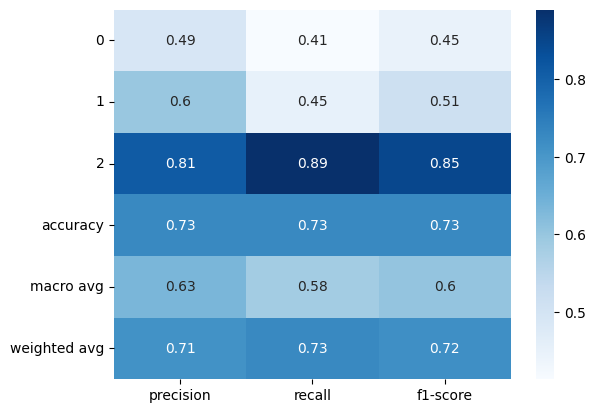

In [11]:
# Create a classification report and use seaborn to show it.
predictions_LSTM = best_model_LSTM.predict(X_test_LSTM)
clf_report_LSTM = classification_report(np.argmax(y_test_LSTM, axis = 1), np.argmax(predictions_LSTM, axis = 1), output_dict = True)

fig, ax = plt.subplots(1,1)
sns.heatmap(pd.DataFrame(clf_report_LSTM).iloc[:-1, :].T, annot=True, cmap="Blues", ax=ax)
fig.savefig('./matplotlib_data/class_rep_lstm')

4030/4030 - 9s - 2ms/step - accuracy: 0.7274 - loss: 0.6027


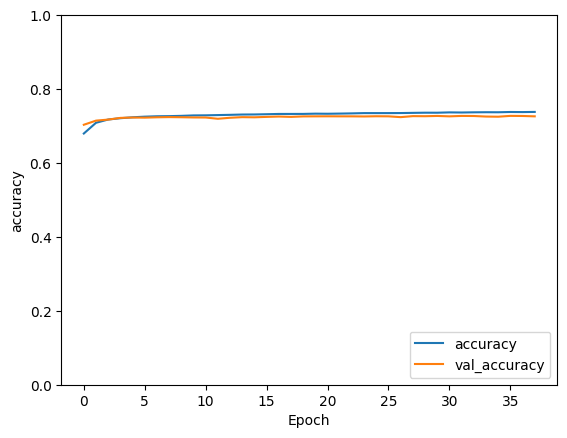

In [12]:
# Create a graph to check overfitting and underfitting.
plt.plot(history_LSTM.history['accuracy'], label='accuracy')
plt.plot(history_LSTM.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.ylim([0.0, 1])
plt.legend(loc='lower right')

test_loss_LSTM, test_acc_LSTM = best_model_LSTM.evaluate(X_test_LSTM, y_test_LSTM, verbose=2)
fig.savefig('./matplotlib_data/over_lstm')

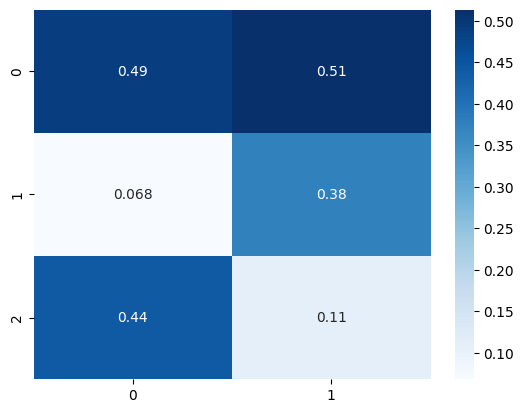

In [13]:
# Create a confusion matrix.
matrix_LSTM = confusion_matrix(y_test_LSTM.argmax(axis = 1), np.around(predictions_LSTM, decimals=0).argmax(axis = 1))

conf_matrix_LSTM = pd.DataFrame(matrix_LSTM, index = ['Neutral','Negative','Positive'],columns = ['Neutral','Negative','Positive'])
conf_matrix_LSTM = np.array(conf_matrix_LSTM).astype('float') / np.array(conf_matrix_LSTM).sum(axis = 1)[:, np.newaxis]

fig, ax = plt.subplots(1,1)
sns.heatmap(pd.DataFrame(conf_matrix_LSTM).iloc[:-1, :].T, annot=True, cmap="Blues", ax=ax)
fig.savefig('./matplotlib_data/conf_matrix_lstm')

#### KNN Model
When we first started testing our KNN model we used different data than our other models. But after careful consideration we wanted to use the same data over all models. Therefore we needed to find a vectorizer which could help convert the sentences to vectors. After testing we found sklearn's `TfidfVectorizer` to be the best fit. We use some of the same parameters as our `Tokenizer` in the LSTM. Only difference is that the words also have to be in five different reviews.

We evaluate the data with both a classification report, confusion matrix and calculation of overfitting.

Source: https://www.geeksforgeeks.org/understanding-tf-idf-term-frequency-inverse-document-frequency/

In [14]:
# Convert the one-hot encoded labels to a 1D array.
labels_convert_KNN = one_hot_encode(y)
labels_convert_KNN = np.argmax(labels_convert_KNN, axis=1)

In [15]:
# Vectorizing the reviews, we use the same features as our tokenizer in the LSTM model.
vectorizer = TfidfVectorizer(max_features = 5000, ngram_range = (1, 1), min_df = 5)
vectorize_reviews = vectorizer.fit_transform(X) 

In [16]:
# Split the data into training and testing sets. Testing on 20% of the data with a random state at 42 because that's the answer to life, the universe, and everything
X_train_KNN, X_test_KNN, y_train_KNN, y_test_KNN = train_test_split(vectorize_reviews, labels_convert_KNN, test_size = 0.2, random_state = 42)

In [17]:
# After a lot of time we found that KNN is a higly inneficient method compared to the other models. More details on this in the conclution.
k = 13
model_KNN = KNeighborsClassifier(n_neighbors = k)
model_KNN.fit(X_train_KNN, y_train_KNN)
y_pred_train = model_KNN.predict(X_train_KNN)
y_pred_test = model_KNN.predict(X_test_KNN)
# 67m 49s

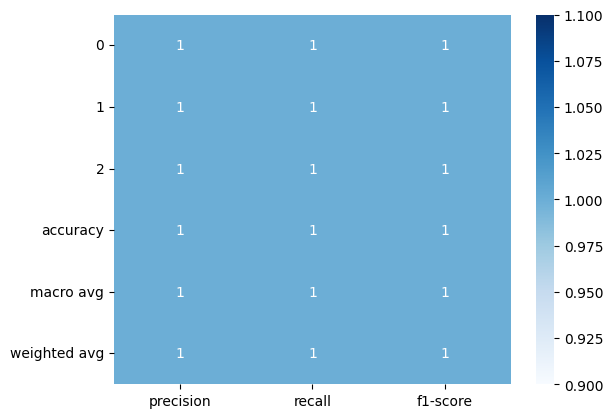

In [ ]:
# Creating a classification report
y_pred_KNN = model_KNN.predict(X_test_KNN)
clf_report_KNN = classification_report(y_test_KNN, y_pred_KNN, output_dict = True)

# Create a classification report and use seaborn to show it.
fig, ax = plt.subplots(1,1)
sns.heatmap(pd.DataFrame(clf_report_KNN).iloc[:-1, :].T, annot=True, cmap="Blues", ax=ax)
fig.savefig('./matplotlib_data/class_rep_knn')

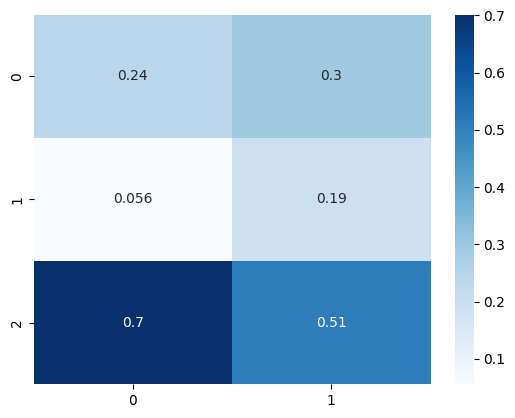

In [19]:
# Creating a confusion matrix
matrix_KNN = sklearn.metrics.confusion_matrix(y_test_KNN, y_pred_KNN)

conf_matrix_knn = pd.DataFrame(matrix_KNN, index = ['Neutral','Negative','Positive'],columns = ['Neutral','Negative','Positive'])
conf_matrix_knn = np.array(conf_matrix_knn).astype('float') / np.array(conf_matrix_knn).sum(axis = 1)[:, np.newaxis]

fig, ax = plt.subplots(1,1)
sns.heatmap(pd.DataFrame(conf_matrix_knn).iloc[:-1, :].T, annot=True, cmap="Blues", ax=ax)
fig.savefig('./matplotlib_data/conf_matrix_knn')

Training Accuracy: 0.7086332678930658
Testing Accuracy: 0.6676910846550588

Classification Report:
               precision    recall  f1-score   support

           0       0.42      0.24      0.31     25473
           1       0.48      0.19      0.28     10692
           2       0.72      0.90      0.80     66983

    accuracy                           0.67    103148
   macro avg       0.54      0.45      0.46    103148
weighted avg       0.62      0.67      0.63    103148



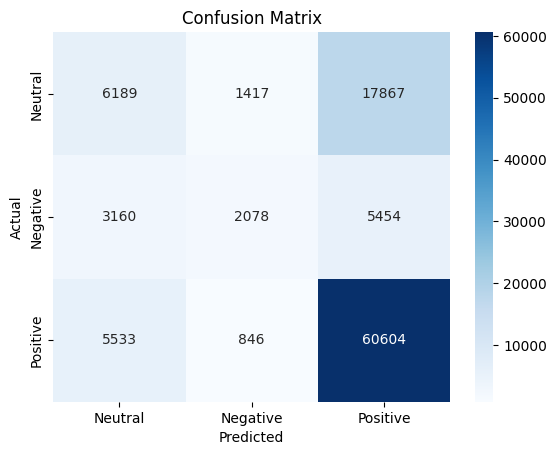

In [20]:
# Creating a graph to check over/under-fitting
print("Training Accuracy:", accuracy_score(y_train_KNN, y_pred_train))
print("Testing Accuracy:", accuracy_score(y_test_KNN, y_pred_test))
print("\nClassification Report:\n", classification_report(y_test_KNN, y_pred_test))

conf_matrix = confusion_matrix(y_test_KNN, y_pred_test)
sns.heatmap(
    conf_matrix, annot = True, fmt = 'd', cmap = 'Blues',
    xticklabels = ['Neutral', 'Negative', 'Positive'],
    yticklabels = ['Neutral', 'Negative', 'Positive']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## TRENGS Å KJØRE PÅ NYTT, FEIL K


This output shows that the model is heavily leaning towards a positive result, where almost all of the entries is registerd as positive. The model also gives many false positives that should be neutral or false. The training set has a fairly high accuracy with ~69% correct and the actual testing set has an accuarcy of 66% which is also fairly high. The model also has low overfitting. 



#### NLP Model

We use this model since Natural Language Processing models are widely used when tackling sentiments analysis.

As per "Zubair Ashfaque" from "https://medium.com/@zubairashfaque/sentiment-analysis-with-naive-bayes-algorithm-a31021764fb4":  

__Sentiment Analysis with the Naive Bayes algorithm is a powerful approach, using probability and linguistic analysis to categorize text sentiments as positive, negative, or neutral. By preprocessing text, calculating log priors, and deriving log-likelihoods, this method quantifies sentiment, guiding accurate classification.__

<br>

After doing some testing with both `MultinomialNB` and `BernoulliNB` we found that `MultinomialNB` had the best accuracy with our data which is our score metric to our models. In addition we also experimented with `CountVectorizer` and `TfdifVectorizer` and found that `CountVectorizer` was a better fit with the data to get the most accurate model. Even though `TfdifVectorizer` was better overall at finding positive reviews.

In [21]:
# Since the dataset is so huge, we use the 5000 of the most common words, and we want to use the words that contains in at least 5 reviews. In addition we use words
# that are in a maximum of 60% of our reviews to remove non meaningful words.
cv = CountVectorizer(max_features = 5000, min_df = 5, max_df = 0.6)
X_nlp = cv.fit_transform(X)

X_train_NLP, X_test_NLP, y_train_NLP, y_test_NLP = train_test_split(X_nlp, y, test_size = 0.2, random_state = 42)

In [22]:
# Train the model
print("MultinomialNB:")
nlp_model = MultinomialNB()
nlp_model.fit(X_train_NLP, y_train_NLP)

MultinomialNB:


MultinomialNB()

{'negative': {'precision': 0.4023205002636932, 'recall': 0.4994388327721661, 'f1-score': 0.4456499061130816, 'support': 10692.0}, 'neutral': {'precision': 0.4178254254679263, 'recall': 0.4635888980489145, 'f1-score': 0.43951913056423997, 'support': 25473.0}, 'positive': {'precision': 0.8261539959748101, 'recall': 0.7599092307003269, 'f1-score': 0.7916481978303977, 'support': 66983.0}, 'accuracy': 0.6597316477294761, 'macro avg': {'precision': 0.5487666405688099, 'recall': 0.5743123205071359, 'f1-score': 0.5589390781692397, 'support': 103148.0}, 'weighted avg': {'precision': 0.6813816163584809, 'recall': 0.6597316477294761, 'f1-score': 0.6688227677152973, 'support': 103148.0}}


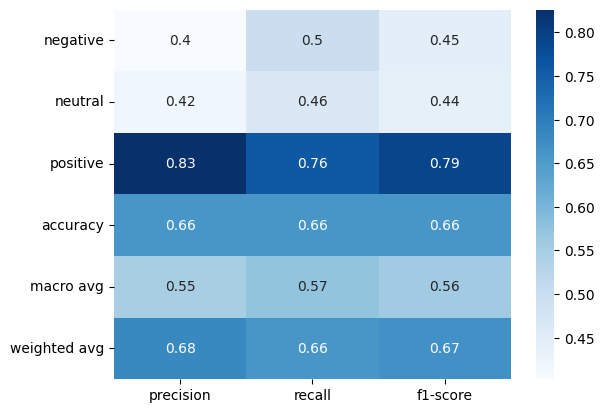

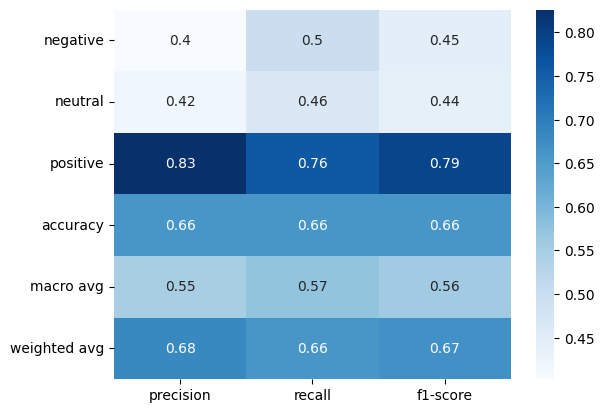

In [23]:
# Creating a classification report
y_pred_nlp = nlp_model.predict(X_test_NLP)
clf_report_NLP = classification_report(y_test_NLP, y_pred_nlp, output_dict = True)
print(clf_report_NLP)

sns.heatmap(pd.DataFrame(clf_report_NLP).iloc[:-1, :].T, annot = True, cmap = "Blues")

fig, ax = plt.subplots(1,1)
sns.heatmap(pd.DataFrame(clf_report_NLP).iloc[:-1, :].T, annot=True, cmap="Blues", ax=ax)
fig.savefig('./matplotlib_data/clf_report_NLP')

<Figure size 500x500 with 0 Axes>

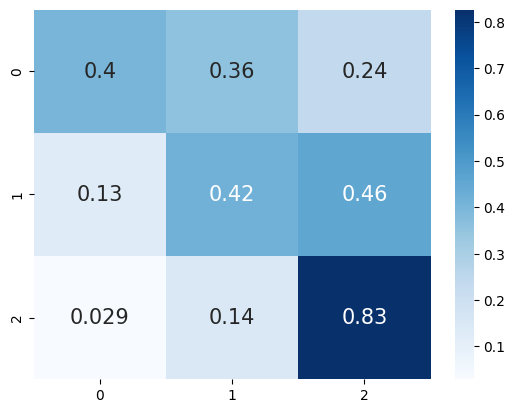

In [24]:
# Creating a confusion matrix
matrix_nlp = sklearn.metrics.confusion_matrix(y_pred_nlp, y_test_NLP)

conf_matrix = pd.DataFrame(matrix_nlp, index = ['Neutral','Negative','Positive'],columns = ['Neutral','Negative','Positive'])
conf_matrix = np.array(conf_matrix).astype('float') / np.array(conf_matrix).sum(axis = 1)[:, np.newaxis]
plt.figure(figsize = (5,5))
fig, ax = plt.subplots(1,1)
sns.heatmap(conf_matrix, annot = True, annot_kws = {"size": 15}, cmap = "Blues", ax=ax)
fig.savefig('./matplotlib_data/conf_mat_nlp')

#### CNN Model
We thought it would be cool to try and use a convolutional network for sentiment analysis of the reviews.

##### <u>Preparation deviations</u>
* The review score value is rounded and a category id is assigned to the review based on it's score. It uses the same thresholds as the other models.
* Then the output category ids are one-hot encoded for each review.
* `dataset_preparation()` returns the cleaned data, as well as the length of the review with the most words.

##### <u>Vectorization</u>

The words are then converted to vectors to reduce processing time. The function `dataset_vectorization()` is used for this. The word-vectors cannot have just one channel with the word encoded into a number as an id representing it because of how gradient descent works. The neural network uses gradient descent, which assumes that the function is continuous, that the output interpolates smoothly between two input vectors, as the values of one vector interpolate into the other vector. This excludes id encoding, because words with ids close to each other are not at all guarranteed to have similar meanings, and for one dimension, it is basically impossible as the set of words grows, given that words have many "axies" of meaning.

One-hot encoding won't work either:
1. Because it would require a number of channels for the word-vector equal to the number of words. This excludes this approach because of how much memory and processing time it would require.

2. Because the input vectors would be far to sparse with meaning to draw anything out of, which is why this encoding style isn't used for these kinds of networks. //// SOURCE

One solution to this is turning the words into vectors using a system that can somehow figure out commonalities between the words or how they relate to each other or any kind of pattern, and then figure out a number of "axies" of meaning for each word. One such system is implemented by the `Word2Vec` class in `gensim`. It takes a model for vectorization and trains itself according to the model and a set of words provided. After this, a word can be inputted to the Word2Vec instance, and it will return an array of values. This array is the vector we use to represent the word, which we feed into the network. //// SOURCE

After this step, the array structure should look something like this:
```python
datasetX: [ [ [ float32, ... (k) ], ... (m) ] ... (n) ]
```
where `n` is the number of reviews, `m` is the length of the review, and `k` is the dimension of the word-vector.

We see that the reviews may have varying numbers of words, meaning that the arrays of word vectors would vary in length. To feed the array into the network, it needs to be converted to a tensor. The problem is that tensors are required to be like transcendentally rectangular, and the arrays of words varying in length is not comaptible with that. We did assume that a CNN with a convolutional layer as the input would be able to account for this, since the layer just strides from one end of the texture to the other, but apparently tensorflow doesn't like that.

To solve this, I just padd the reviews to the length of the longest review, with word vectors where all the numbers are 0. This should be fine, since the vectorizer makes word vectors with values from -1 to 1, so 0 would be neutral; that the word vector has no meaning on that axis.

The number of fragment channels was chosen based on testing. A larger number of channels consistently gave better results, and we assume that this trend would probably continue up until a number of channels that is some larger fraction of the total number of unique words in all the reviews, but more channels increases memory usage and training time, so we never really got to test this theory on the entire dataset. We assume that as the number of channels reaches past a quarter of all the unique words, the network would start to perform worse, since there would be too many channels and not enough words to generate meaning, leading to a similar situation as the one-hot encoding, that when it equals to the number of unique words, it would be equivalent to be like a padded out one-hot encoding. Again, we didn't get to actually test the one hot encoding, and we didn't get to test larger numbers of channels, so we can't really show data to attest to this theory.


##### <u>Defining the model</u>

The model uses a convolutional layer as input. The size and stride length of the filters was chosen based on testing. We found that these values were the ones that gave the best results. //// DOUBLE CHECK THIS: // A to small of a filter didn't perform very well. We theorize that this is because words in a sentence relate to each other across larger distances in a stream of speech or text, so a wider filter would do better. What we also saw was that when the filter was too large, it performed worse. We theorize that this is because words that are to far appart, don't mean much for each other, at least not as much as words that are close to each other, so they would mostly just be noise in the filter.

The 1D convolutional layer, gives a 2D output because there is a neuron for each channel of the fragments in the texture, so there is 1 dimension from the fragment channels and 1 dimension from the convolutional layer dimensionality. We use a flatten layer after the convolutional layer to turn the 2D output of the layer into a 1D output. All the outputs are kept in tact, just sequenced into a line.

We use a couple more layers after the convolutional layer to properly interpret the output of it and narrow it down to the three categories:
* positive 
* neutral
* negative

We use dropout layers in between the other layers, because by disregarding some of the inputs from one layer to the next, it makes the network more resilient. If a layer can't rely on the value of a neuron to always be usable, it has to find other patterns to reinforce, which makes the network spread the pattern recognition wider across the neurons in the layer.
//// SOURCE: https://medium.com/@utsavraj.ptn04/dropping-the-knowledge-bomb-understanding-dropout-layers-in-deep-learning-0612f517269d

The model uses early stopping in relation to loss. This is because if the model starts to perform worse with training, it is important to stop it when it is close to its peak. We have given the model a higher patience value, this is because we wanted it to try a little harder before giving up. This relates to the graphs that we saw, where accuracy tended to have some ups and downs, so the model should be a little more cool and levelheaded and hold the stocks a little longer. Also it was a bit sad to see the model give up after 10 out of 50 epochs.


In [4]:
import pandas as pd

#############
# DATAFRAME CONVERZZION

def dataframe_convertion(_dataset):
    _merged_reviews = []
    for i in _dataset.to_numpy():
        _merged_reviews.append({ "score": i[2], "review": i[0] + " " + i[1] })
    
    return _merged_reviews

In [5]:
#############
# DATASET EXTRAXXION

from typing import Iterable

def entry_extraction(_entry, _col):
    _entry_extract = []
    if isinstance(_entry[_col], Iterable):
        for _word in _entry[_col]:
            _entry_extract.append(_word)
        return _entry_extract
    else:
        return _entry[_col]

def dataset_extraction(_dataset, _col):
    _dataset_extract = []
    for _entry in _dataset:
        _entry_extract = entry_extraction(_entry, _col)
        _dataset_extract.append(_entry_extract)
    return _dataset_extract

In [6]:
#############
# DATASET PREPARATION

import re
import nltk
# YO JUST TRY TO MOVE THIS STUFF AWAY FROM THIS CODE SECTION AGAIN, SEE WHAT HAPPENS
# DO IT MATE, MOVE IT UP TO THE TOP WITH ALL THE OTHER IMPORTS, TRY IT!
# I SWEAR, ONCE MORE
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
from gensim.models import Word2Vec;

def string_clean(_string):
    _string = _string.lower()
    _string = re.sub(r"\d+", "", _string)
    _string = re.sub(r"[^\w\s]", "", _string)
    return _string

def lemma_string(_string):
    _text = nltk.word_tokenize(_string)
    _text_lemma = []
    for _word in _text:
        _word_lemma = WordNetLemmatizer().lemmatize(_word)
        if not _word_lemma in stop_words:
            _text_lemma.append(_word_lemma)
    return _text_lemma

def dataset_preparation(_dataset, _mode = "lemma"):
    _dataset_prepare = []
    _entry_longest = 0
    if _mode == "lemma":
        for _review in _dataset:
            _review_prepare = { "score": _review["score"], "review": lemma_string(string_clean(_review["review"])) }
            _dataset_prepare.append(_review_prepare)
            if len(_review_prepare["review"]) > _entry_longest:
                _entry_longest = len(_review_prepare["review"])
    else:
        raise ValueError("provided preparation mode does not exist")

    return _dataset_prepare, _entry_longest

In [53]:
#############
# SCORE: (abstract python decimal number) TO LABEL CONVERZZION

const_label_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2,
}

const_label_unmap = {
    0: "negative",
    1: "neutral",
    2: "positive",
}

const_score_map = {
     0: 0,
     1: 0,
     2: 0,
     3: 0,
     4: 0,
     5: 0,
     6: 0,
     7: 1,
     8: 1,
     9: 2,
    10: 2,
}

def entry_label_convertion( _score ):
    return const_score_map[round(_score)]

In [62]:
#############
# DATASET VECTORIZATION GENERATOR

import numpy as np
import tensorflow as tf
from tensorflow import dtypes
import math

class VectorizerIterator:
    def __init__(_self, _dataset_x, _dataset_y, _model, _resolution, _channels, _categories):
        _dataset_length = len(_dataset_x)
        if len(_dataset_y) != _dataset_length:
            raise ValueError("cannot split dataset provided dataset components do not have the same length.")
        _self.i = 0
        _self.model = _model
        _self.resolution = _resolution
        _self.channels = _channels
        _self.categories = _categories
        _self.dataset_x = _dataset_x
        _self.dataset_y = _dataset_y
        _self.dataset_length = len(_dataset_x)

        print(_self.dataset_length)

    def __iter__(_self):
        _self.i = 0
        return _self

    def __next__(_self):
        return _self._dataset_vectorize()

    def _increment(_self):
        _self.i += 1

    def _dataset_vectorize(_self):
        if( _self.i >= _self.dataset_length ):
            _self.i = 0
            raise StopIteration
            
        
        _x = np.zeros((_self.resolution, _self.channels), dtype = np.float32)
        _y = np.zeros((_self.categories), dtype = np.int8)

        _entry_x = _self.dataset_x[_self.i]
        _entry_x_length = len(_entry_x)

        j = 0
        while j < _self.resolution and j < _entry_x_length:
            _word = _entry_x[j]
            if _word in _self.model.wv:
                _word_vecc = _self.model.wv[_word]
                k = 0
                while k < _self.channels:
                    _x[j][k] = _word_vecc[k]
                    k += 1
            j += 1
        
        _entry_y = _self.dataset_y[_self.i]
        _y[entry_label_convertion( _entry_y )] = 1
        
        _self._increment()
            
        return (_x, _y)
    

In [71]:
import psutil
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import data
import math



""" does the data very thoroughly, really properly does it

does data to following format:

n = number of reviews
m = number of words in review
k = number of channels per vectorized word

      dataset: [ entry, ... (n) ]
        entry: { "review": texture, "score": socre }
      texture: [ fragment, ... (m) ]
     fragment: [ colourChannel, ... (k) ]
colourChannel: float32
        score: [ int8, int8, int8 ]

dataset: [ [ [ [ float32, ... (k) ], ... (m) ], [ int8, int8, int8 ] ] ... (n) ]

datasetX: [ texture ... (n) ]
datasetY: [ score ... (n) ]

returns the dataset split in three
returns 70% for training
returns 15% for validation
returns 15% for test

"""
def do_data(_path, _preparation_mode = "lemma", _fragment_channels = 100, _vectorization_mode = "skip", _batch_size = 64):
    if _vectorization_mode != "skip" and _vectorization_mode != "bow":
        raise ValueError("provided vectorization mode does not exist")

    _10_power_2 = 1024
    _python = psutil.Process()
    print("  >>> memory usage: %.2f gb" % float(_python.memory_info().rss / (_10_power_2 * _10_power_2 * _10_power_2)))

    print("  # # started preparation")
    
    print("        # loading from csv")
    _dataset = pd.read_csv(_path, usecols = ["Negative_Review", "Positive_Review", "Reviewer_Score"])
    print("      >>> memory usage: %.2f gb" % float(_python.memory_info().rss / (_10_power_2 * _10_power_2 * _10_power_2)))

    print("        # performing converzzion")
    _dataset = dataframe_convertion(_dataset)
    _dataset, _resolution_largest = dataset_preparation(_dataset, _mode = _preparation_mode)
    print("      >>> memory usage: %.2f gb" % float(_python.memory_info().rss / (_10_power_2 * _10_power_2 * _10_power_2)))

    print("        # performing extraxxion")
    _dataset_x = dataset_extraction(_dataset, "review")
    _dataset_y = dataset_extraction(_dataset, "score")
    print("      >>> memory usage: %.2f gb" % float(_python.memory_info().rss / (_10_power_2 * _10_power_2 * _10_power_2)))
    _dataset = None
    print("      >>> memory usage: %.2f gb" % float(_python.memory_info().rss / (_10_power_2 * _10_power_2 * _10_power_2)))
    
    print("    # finished preparation")

    print("  # # started vectorization")
    
    print("        # training vectorization model")
    _model = None

    if _vectorization_mode == "skip":
        _model = Word2Vec(_dataset_x, min_count = 1, vector_size = _fragment_channels, window = 5, sg = 1)
    elif _vectorization_mode == "bow":
        _model = Word2Vec(_dataset_x, min_count = 1, vector_size = _fragment_channels, window = 5)
    else:
        raise ValueError("provided vectorization mode does not exist")
    print("      >>> memory usage: %.2f gb" % float(_python.memory_info().rss / (_10_power_2 * _10_power_2 * _10_power_2)))
    print("        # performing vectorization and splitting")
    
    _train_x, _other_x, _train_y, _other_y = train_test_split(_dataset_x, _dataset_y, test_size = 0.3, random_state = 2)
    _dataset_x = None
    _dataset_y = None

    _validate_x, _test_x, _validate_y, _test_y = train_test_split(_other_x, _other_y, test_size = 0.5, random_state = 2)
    _other_x = None
    _other_y = None
    
    _vectorizer_train = VectorizerIterator(_train_x, _train_y, _model, _resolution_largest, _fragment_channels, len(const_label_map))
    _dataset_train = data.Dataset.from_generator( lambda: _vectorizer_train, output_types = (tf.float32, tf.int8), output_shapes = ((_resolution_largest, _fragment_channels), (len(const_label_map)))).batch(_batch_size)
    
    _vectorizer_validate = VectorizerIterator(_validate_x, _validate_y, _model, _resolution_largest, _fragment_channels, len(const_label_map))
    _dataset_validate = data.Dataset.from_generator( lambda: _vectorizer_validate, output_types = (tf.float32, tf.int8), output_shapes = ((_resolution_largest, _fragment_channels), (len(const_label_map)))).batch(_batch_size)
    
    _vectorizer_test = VectorizerIterator(_test_x, _test_y, _model, _resolution_largest, _fragment_channels, len(const_label_map))
    _dataset_test = data.Dataset.from_generator( lambda: _vectorizer_test, output_types = (tf.float32, tf.int8), output_shapes = ((_resolution_largest, _fragment_channels), (len(const_label_map)))).batch(_batch_size)

    print("      >>> memory usage: %.2f gb" % float(_python.memory_info().rss / (_10_power_2 * _10_power_2 * _10_power_2)))
    print("    # finished vectorization")
    print("  # # outputting dataset")
    print("  >>> memory usage: %.2f gb" % float(_python.memory_info().rss / (_10_power_2 * _10_power_2 * _10_power_2)))
    
    return _dataset_train, _dataset_validate, _dataset_test, _resolution_largest

In [ ]:
#############
# NETWORK: DEFINING /// COMPILING /// TRAINING

import tensorflow as tf
from tensorflow import keras
from keras import layers, datasets, models, callbacks

def make_model(_dataset_train, _dataset_validate, _resolution, _channels, _epochs, _steps):
    print("    # started model")
    with tf.device("/GPU:0"):
        _model = models.Sequential()
        _model.add( layers.Input( shape = (_resolution, _channels), dtype = tf.float32 ) )
        _model.add( layers.Conv1D(48, 8, activation = "relu", strides = 2, data_format = "channels_last") )
        _model.add( layers.BatchNormalization())
        _model.add( layers.MaxPooling1D((2)))
        _model.add( layers.Dropout(0.3))
        _model.add( layers.Conv1D(96, 16, activation = "relu", strides = 1))
        _model.add( layers.BatchNormalization())
        _model.add( layers.MaxPooling1D((2)))
        _model.add( layers.Dropout(0.3))
        _model.add( layers.Dense(192, activation = "relu"))
        _model.add( layers.Flatten())
        _model.add( layers.BatchNormalization())
        _model.add( layers.Dropout(0.4))

        _model.add( layers.Dense(64, activation = "relu"))
        _model.add( layers.Dropout(0.2))
        _model.add( layers.Dense(96, activation = "relu"))
        _model.add( layers.Dropout(0.2))
        _model.add( layers.Dense(12, activation = "relu"))
        _model.add( layers.Dropout(0.2))
        _model.add( layers.Dense(3, activation = "softmax"))
        _model.compile(
            optimizer = "adam",
            # loss = keras.losses.CategoricalCrossentropy(from_logits = False),
            loss = keras.losses.BinaryCrossentropy(),
            metrics = ["accuracy"],
        )

        _early_stopping = callbacks.EarlyStopping(monitor = "val_loss", patience = 5, restore_best_weights = True)

        _history = _model.fit(
            _dataset_train,
            epochs = _epochs,
            steps_per_epoch = _steps,
            validation_data = _dataset_validate,
            callbacks = [_early_stopping],
        )
    print("    # model training finished")
    return _model, _history

In [73]:
#############
# EVALUATION /// VISUALIZATION
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

def un_hotten(_one_hot):
    _length = len(_one_hot)
    _largest = 0;
    for _i in range(_length):
        if float(_one_hot[_i]) > float(_one_hot[_largest]):
            _largest = int(_i)
    return _largest

def evaluate_model(_model, _dataset_test):
    print("  # # evaluating model")
    _loss, _accuracy = _model.evaluate(_dataset_test, verbose = 0)

    print( "  >>> LOSS:     " + str(_loss), "\n  >>> ACCURACY: " + str(_accuracy) )

    _predictions_ = _model.predict(_dataset_test)
    iter(_dataset_test)
    _y_ = []
    _y = []
    for _i in _dataset_test:
        for _j in _i[1]:
            _a = []
            for _k in _j:
                _a.append(float(_k))
            _y_.append(_a)
            _y.append(const_label_unmap[un_hotten(_a)]);
    
    _predictions = []
    for _i in _predictions_:
        _a = []
        for _j in _i:
            _a.append(float(_j))
        _predictions.append(const_label_unmap[un_hotten(_a)]);
    _matrix = confusion_matrix(_y, _predictions)
    print(classification_report(np.argmax(np.asarray(_y_, dtype = np.int8), axis = 1), np.argmax(_predictions_, axis = 1)))
    _confusion_matrix = pd.DataFrame(_matrix, index = ["Negative","Neutral","Positive"], columns = ["Negative","Neutral","Positive"])
    print(_confusion_matrix)
    _10_power_2 = 1024
    _python = psutil.Process()
    print("      >>> memory usage: %.2f gb" % float(_python.memory_info().rss / (_10_power_2 * _10_power_2 * _10_power_2)))

    return _confusion_matrix

def plotAll(_history, _confusion_matrix):
    plt.plot(_history.history["accuracy"], label = "accuracy")
    plt.plot(_history.history["val_accuracy"], label = "val_accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.ylim([0.5, 1])
    plt.legend(loc = "lower right")
    plt.show()

    _confusion_matrix = np.array(_confusion_matrix).astype("float") / np.array(_confusion_matrix).sum(axis=1)[:, np.newaxis]
    _confusion_matrix = pd.DataFrame(_confusion_matrix, index = ["Negative","Neutral","Positive"], columns = ["Negative","Neutral","Positive"])
    plt.figure(figsize = (5, 5))
    sns.heatmap(_confusion_matrix, annot = True, annot_kws = {"size": 15})

# print(tf.convert_to_tensor(list(const_label_map.values())))
#_predictions = _model.predict(_dataset_test)
#print(_matrix = tfmath.confusion_matrix(tf.convert_to_tensor(list(const_label_map.values())), _predictions))


  >>> memory usage: 2.21 gb
  # # started preparation
        # loading from csv
      >>> memory usage: 2.36 gb
        # performing converzzion
      >>> memory usage: 3.34 gb
        # performing extraxxion
      >>> memory usage: 3.42 gb
      >>> memory usage: 3.42 gb
    # finished preparation
  # # started vectorization
        # training vectorization model
      >>> memory usage: 3.22 gb
        # performing vectorization and splitting
361016
77361
77361
      >>> memory usage: 3.23 gb
    # finished vectorization
  # # outputting dataset
  >>> memory usage: 3.23 gb
    # started model
Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 241s 3s/step - accuracy: 0.4279 - loss: 0.7207 - val_accuracy: 0.5688 - val_loss: 0.5894
Epoch 2/50


c:\Users\ivans\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


72/72 ━━━━━━━━━━━━━━━━━━━━ 232s 3s/step - accuracy: 0.5561 - loss: 0.6027 - val_accuracy: 0.5688 - val_loss: 0.5568
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 232s 3s/step - accuracy: 0.5573 - loss: 0.5730 - val_accuracy: 0.5688 - val_loss: 0.5748
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 229s 3s/step - accuracy: 0.5781 - loss: 0.5202 - val_accuracy: 0.5699 - val_loss: 0.5483
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 221s 3s/step - accuracy: 0.6124 - loss: 0.4978 - val_accuracy: 0.5730 - val_loss: 0.5319
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 224s 3s/step - accuracy: 0.6176 - loss: 0.4745 - val_accuracy: 0.5806 - val_loss: 0.5998
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 220s 3s/step - accuracy: 0.6281 - loss: 0.4751 - val_accuracy: 0.6376 - val_loss: 0.4507
Epoch 8/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 222s 3s/step - accuracy: 0.6383 - loss: 0.4681 - val_accuracy: 0.6646 - val_loss: 0.4529
Epoch 9/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 223s 3s/step - accuracy: 0.6334 - loss: 0.4669 - val_accuracy: 0.6658 - val_loss: 0.

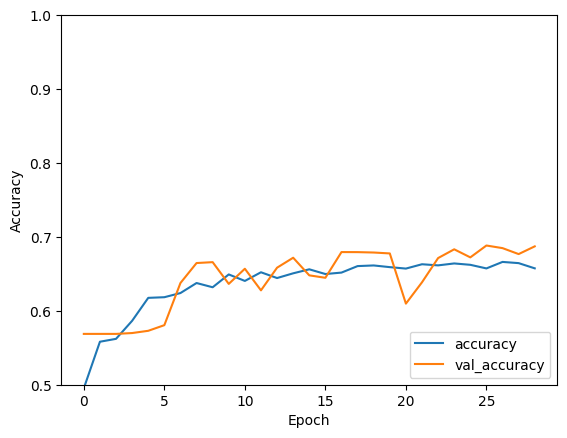

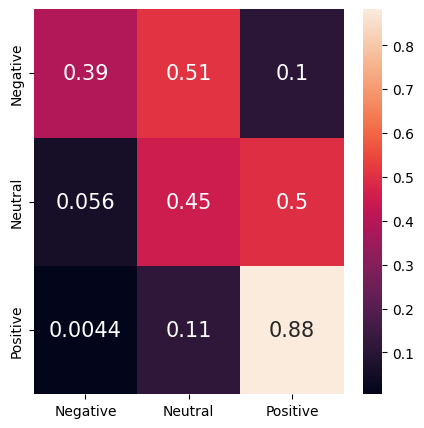

In [75]:
#############
# ACTUALLY DOING EVERYTHING

fragment_channels = 256
epochs = 50
steps = 72
batch_size = 128

dataset_train, dataset_validate, dataset_test, resolution = do_data(
    "Hotel_Reviews.csv",
    _fragment_channels = fragment_channels,
    _vectorization_mode = "skip",
    _batch_size = batch_size,
)

_model, _history = make_model(dataset_train, dataset_validate, resolution, fragment_channels, epochs, steps)

_confusion_matrix = evaluate_model(_model, dataset_test)
plotAll(_history, _confusion_matrix)

## dereferencing for garbage collection
dataset_train = None
dataset_validate = None
dataset_test = None
_model = None
_history = None


### Taks 1 Conclution 
#### Task a)
To conclude this sub-task which was to understand and prepare the data for our models. We explained what data we used and how we cleaned them. The only thing we should have done was to undersample it as it affected our models quite much.

#### Task b)
Here we evaluate each model and explain how well it did.

##### LSTM
* We start with our classification report. When first looking at it seems like it did good, accuracy is fairly high with a high precision, recall and f1-score. But that only applies for our positive revewis. By further analysing it we can see it did worse with negative and neutral review, which is explained by our imbalanced dataset. As we didn't undersample our data the model has a higher chance to predict positive as it trained mostly on those reviews. We can see this further in our confusion matrix where it has a shows our model is more postive oriented. Lastly our graph is very good, no overfittig or underfitting.
* The model is a simple built neural network and does okay, but it could have been much better with a balanced dataset.

##### KNN
* As the LSTM model, our KNN's classification report have the same problems. It does well on positives but worse on negative and neutral. As we explained above this is caused by our imbalanced dataset, the confusion matrix further proves this also.
* This model was not time efficient, but it did suprisngly better than what we expected.

##### NLP
* When looking at the classification report we see the same trend as our previous models. Again we are reminded of our stupidity and how not doing one simple thing impacted this much in our models.
* NLP is a powerful model for this task, but with an imbalanced dataset it becomes an okay model.

##### CNN
* As our previous models our CNN model also shows the same affects. It is very good for positive reviews, but falls with negative and neutral. Confusion matrix further proves this. But our graph shows that it didn't overfit much and means our data is good and our models isn't to complicated.
* This model is quite more complex and complicated to our other models. But after a lot of work it works quite well for a model that is build for understanding pictures.

To summarize shortly we have understood and cleaned a big dataset of reviews. We have made four models that can predict if a review is positive, neutral or negative and evaluated each one. The only big thing we should have done differently was to undersample our data to make our models even better.

# Task 2 Convolution Neural Network
#### a) 
##### Sources used to guide this task: "https://medium.com/x8-the-ai-community/solving-class-imbalance-problem-in-cnn-9c7a5231c478" and "https://medium.com/@seelcs12/cnns-for-imbalanced-image-classification-with-tensorflow-7284a8c4a2e4"

In [39]:
# Load CIFAR-10 dataset and split int training and testing sets
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

The representation of the data was evaluated, and we found that changing the labels into a binary relation, would helped us when getting the CNN to fit our task. Our model was going to identify frogs as our target class, which was the label `[6]` in the dataset.

In [40]:
num_class = 6

for n in range(len(y_train)):
    if y_train[n] == [num_class]:
        y_train[n] = [1]
    else:
        y_train[n] = [0]

for n in range(len(y_test)):
    if y_test[n] == [num_class]:
        y_test[n] = [1]
    else:
        y_test[n] = [0]

#### Undersampling the data

After training and testing we found the dataset quite imbalanced for our task. As we only have 5000 frogs and 45000 non frogs, we decided to undersample our non frogs. But for our test data we decided to keep all the photos for better learning.

In [41]:
x_tr_frog = []
y_tr_frog = []
for n in range(len(y_train)):
    if y_train[n] == [1]:
        x_tr_frog.append(x_train[n])
        y_tr_frog.append([1])

for n in range(len(y_train)):
    if len(x_tr_frog) < 10000:
        x_tr_frog.append(x_train[n])
        y_tr_frog.append([0])

x_tr_frog = np.array(x_tr_frog)
y_tr_frog = np.array(y_tr_frog)

##### <u>The model</u>

Createing `make_model()` and start with 32 units of `Conv2D` with input size set to image size. Went with activation `relu`. Than a `BatchNormalization` which finds the optimal solution faster. Then reduce the size with `MaxPooling2D` to extract the valuable features. This is the base layer of the model, which we use two more times. In the last layer we start by `Flatten` to get one single vector. Then we add 128 units of `Dense` with the same activation. In addition we add a `kernel_regularizer` to help the models weights. We used `Dropout` layers for each `Dense` to prevent overfitting. Our last `Dense` will serve as our output and therefore we use the activation `sigmoid` to make the model create a score between 0 and 1. We also increased our `batch_size` to 128 to prevent spikes in our graph to check overfitting/underfitting. `early_stopping`was used to not waste time training when the model has reached it's peak.

In [42]:
def make_model(metric, x_train, y_train, x_val, y_val):
    with tf.device('/GPU:0'):
        model = models.Sequential()
        model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D((2, 2)))

        model.add(layers.Conv2D(128, (3, 3), activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D((2, 2)))

        model.add(layers.Conv2D(256, (3, 3), activation='relu'))
        model.add(layers.BatchNormalization())

        model.add(layers.Flatten())
        model.add(layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.005)))
        model.add(layers.Dropout(0.4))
        model.add(layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.005)))
        model.add(layers.Dropout(0.4))
        model.add(layers.Dense(1, activation='sigmoid'))

        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[metric])

        early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience = 5, restore_best_weights = True)

        history = model.fit(
            x_train,
            y_train,
            batch_size = 128,
            epochs = 50,
            validation_data = (x_val, y_val),
            callbacks = [early_stopping]
        )
        return model, history

In [43]:
# Training the model. We chose accuracy as the metric as it performed better than other metrics.
acc_model, acc_history = make_model('accuracy', x_tr_frog, y_tr_frog, x_test, y_test)

Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.6968 - loss: 2.5391 - val_accuracy: 0.1002 - val_loss: 2.1137
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.8045 - loss: 1.6351 - val_accuracy: 0.9000 - val_loss: 1.0925
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.8418 - loss: 1.0691 - val_accuracy: 0.8961 - val_loss: 0.9345
Epoch 4/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.8553 - loss: 0.7834 - val_accuracy: 0.9036 - val_loss: 0.5595
Epoch 5/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.8784 - loss: 0.5928 - val_accuracy: 0.8898 - val_loss: 0.5577
Epoch 6/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.8786 - loss: 0.5185 - val_accuracy: 0.8550 - val_loss: 0.4877
Epoch 7/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.8923 - loss: 0.4511 - val_accuracy: 0.8623 - val_loss: 0.4375
Epoch 8/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9075 - loss: 0.3947 - val_accuracy: 0.8025 - v

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


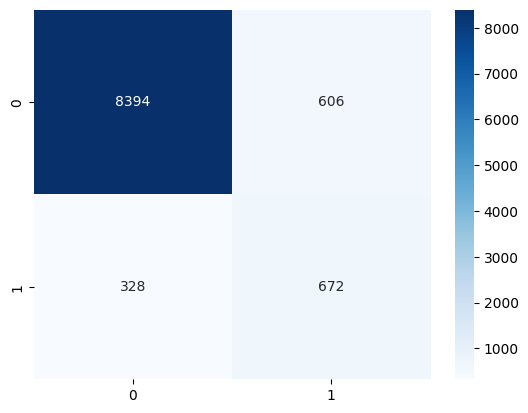

In [44]:
# Create a confusion matrix, uses seaborn to show it.
def made_predictions(predictions):
    array = []
    for pred in predictions:
        if max(pred) > 0.7:
            array.append([1])
        else:
            array.append([0])
    return np.array(array)

y_pred_acc = acc_model.predict(x_test)
y_pred_acc = made_predictions(y_pred_acc)
acc_cf = confusion_matrix(y_test, y_pred_acc)

sns.heatmap(acc_cf, annot=True, cmap='Blues', fmt='d')
fig.savefig('./matplotlib_data/conf_mat_CNN')
fig.show()

313/313 - 1s - 3ms/step - accuracy: 0.8623 - loss: 0.4375


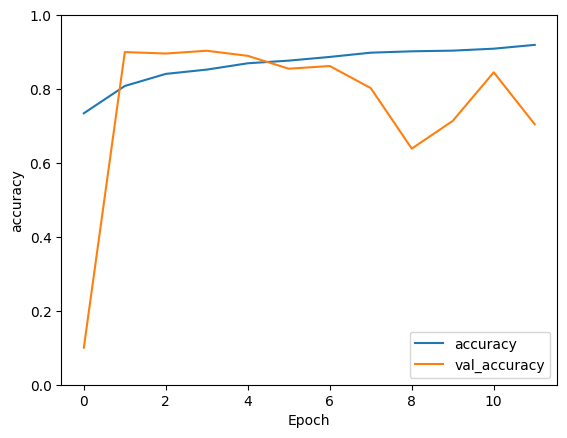

In [45]:
# Create a graph to show overfitting and underfitting.
plt.plot(acc_history.history['accuracy'], label='accuracy')
plt.plot(acc_history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.ylim([0.0, 1])
plt.legend(loc='lower right')
plt.savefig('./matplotlib_data/over_acc_CNN')

test_loss, test_acc = acc_model.evaluate(x_test, y_test, verbose=2)

#### Task 2b)

Found these pictures from Google:

* <u>Image 1</u>
    * https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.wcs.org%2Fget-involved%2Fupdates%2Ffascinating-frogs&psig=AOvVaw28_HGqOe7S2sxjPK3bsI5N&ust=1744278715616000&source=images&cd=vfe&opi=89978449&ved=0CBQQjRxqFwoTCKDFld_WyowDFQAAAAAdAAAAABAE

* <u>Image 2</u> 
    * https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.twinkl.pt%2Fteaching-wiki%2Ffrog&psig=AOvVaw0bdQuBJB9qO9gkRwCWvou-&ust=1744633397275000&source=images&cd=vfe&opi=89978449&ved=0CBQQjRxqFwoTCPCGuIGA1YwDFQAAAAAdAAAAABAE

* <u>Image 3</u>
    * https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.nytimes.com%2Fwirecutter%2Freviews%2Fnew-dog-checklist%2F&psig=AOvVaw2ZPUsP1HTJbZhOYM2tqHPx&ust=1744633423068000&source=images&cd=vfe&opi=89978449&ved=0CBQQjRxqFwoTCND_iI6A1YwDFQAAAAAdAAAAABAE

* <u>Image 4</u>
    * https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.goodwood.com%2Fgrr%2Ff1%2Fthe-nine-best-f1-cars-of-all-time%2F&psig=AOvVaw0_NSf08TH2_7ChAB8GfZhd&ust=1744633440992000&source=images&cd=vfe&opi=89978449&ved=0CBQQjRxqFwoTCNi76pWA1YwDFQAAAAAdAAAAABAE

Used Tensorflows own `load_img` to convert the pictures into the right size. Then we show them in the graph below.

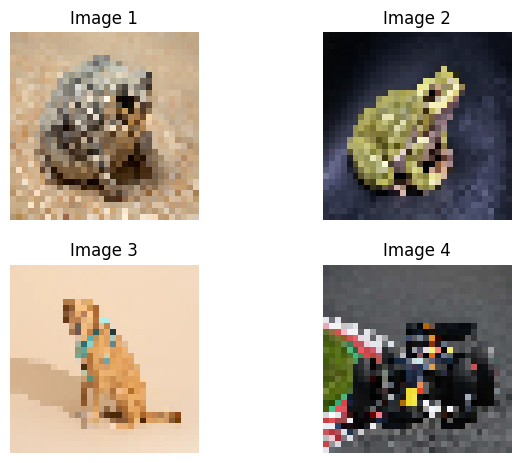

In [46]:
# Showing the pictures we are using to test the models.
images = []

img_1 = tf.keras.utils.load_img('./media/frog_6.jpg', target_size=(32, 32))
img_2 = tf.keras.utils.load_img('./media/frog_4.jpg', target_size=(32, 32))
img_3 = tf.keras.utils.load_img('./media/dog_2.jpg', target_size=(32, 32))
img_4 = tf.keras.utils.load_img('./media/f1.jpg', target_size=(32, 32))

images.append(img_1)
images.append(img_2)
images.append(img_3)
images.append(img_4)

fig, ax = plt.subplots(2, 2)
fig.tight_layout()
ax = ax.flatten()

images_for_model = []
num = 1

for img, ax in zip(images, ax):
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.array(img_array) / 255.0 # Normalize
    images_for_model.append(img_array)
    ax.imshow(img_array)
    ax.set_title(f'Image {num}')
    ax.axis('off')
    num += 1

plt.show()

##### <u>Prediction</u>
When making our predictions we first add a batch to the picture so our model can actually use it to predict. When the model makes a prediction we convert it into a percentage for better reading. We add a threshold to decide if we are going to believe the model or not, we found that 70% worked nicely, print out the result.

In [47]:
# Actual predictions
print("Hi! I'm Accuracy and I think that: ")
for num in range(len(images_for_model)):
    img = images_for_model[num]
    img = tf.expand_dims(img, 0) # Create a batch
    pred = acc_model.predict(img)
    pred = pred[0][0] * 100
    print(f"    Image {num + 1} is: ", end="")
    if pred > 70:
        print(f'{pred:.2f}% a frog.')
    else:
        print(f'{100 - pred:.2f}% not a frog')

Hi! I'm Accuracy and I think that: 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
    Image 1 is: 95.34% a frog.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
    Image 2 is: 75.48% a frog.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
    Image 3 is: 50.44% not a frog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
    Image 4 is: 82.33% not a frog


### Conclusion of task 2.

To shortly summarize, we have created a binary CNN model to predict if a picture is a frog or not. In addition we have optimized most of our model through testing and created an optimal solution to the task. Lastly we also tested the model with pictures from the internet to test our model which worked quite nicely.